# TEST

In [5]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
import pandas as pd
from IPython.display import display

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 350
sigma = 0.25                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

maxdeg = 15

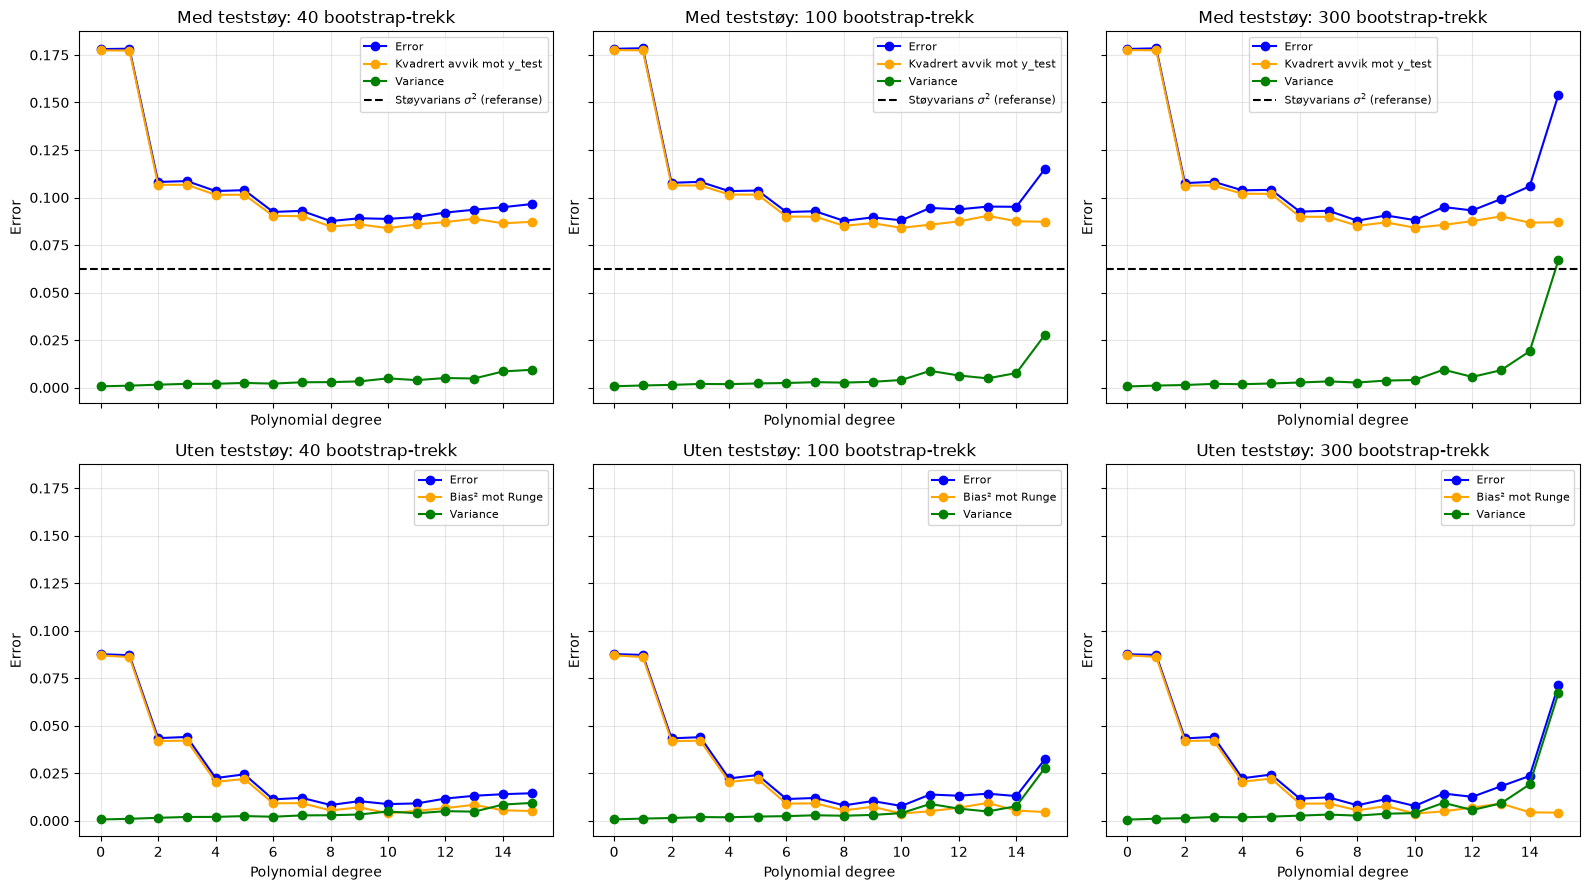

In [43]:
# Bootstrap resampling: samme modeller, to forskjellige testmål.
def bootstrap_bias_variance(n_bs, maxdeg, seed=2026):
    bootstrap_rng = np.random.default_rng(seed)
    bootstrap_seeds = bootstrap_rng.integers(0, 2**32 - 1, size=n_bs)

    error = np.zeros(maxdeg + 1)
    bias = np.zeros(maxdeg + 1)  # Avvik mot støyende y_test, ikke ren bias².
    variance = np.zeros(maxdeg + 1)
    error_clean = np.zeros(maxdeg + 1)
    bias_clean = np.zeros(maxdeg + 1)

    for degree in range(maxdeg + 1):
        X = design_matrix(x, degree)
        # Behold rå x_test, også når designmatrisen bare har konstantkolonnen.
        X_train, X_test, y_train, y_test, x_train, x_test = train_test_split(
            X, y, x, test_size=0.3, random_state=2026
        )
        y_true = runge(x_test)
        y_pred = np.zeros((len(y_test), n_bs))

        for i in range(n_bs):
            X_bs, y_bs = resample(
                X_train, y_train, random_state=int(bootstrap_seeds[i])
            )
            theta = np.linalg.pinv(X_bs) @ y_bs
            y_pred[:, i] = X_test @ theta

        mean_prediction = y_pred.mean(axis=1)
        variance[degree] = np.mean(np.var(y_pred, axis=1))

        # Evaluering mot observerte, støyende testverdier.
        error[degree] = np.mean((y_test[:, None] - y_pred)**2)
        bias[degree] = np.mean((y_test - mean_prediction)**2)

        # Evaluering mot den kjente, støyfrie funksjonen.
        error_clean[degree] = np.mean((y_true[:, None] - y_pred)**2)
        bias_clean[degree] = np.mean((y_true - mean_prediction)**2)

    return error, bias, variance, error_clean, bias_clean


bootstrap_maxdeg = 15
degree_vec = np.arange(bootstrap_maxdeg + 1)
bootstrap_results = {
    count: bootstrap_bias_variance(count, bootstrap_maxdeg)
    for count in [40, 100, 300]
}

# Behold navnene som brukes i senere celler.
error40, bias40, variance40, error40_clean, bias40_clean = bootstrap_results[40]
error100, bias100, variance100, error100_clean, bias100_clean = bootstrap_results[100]
error300, bias300, variance300, error300_clean, bias300_clean = bootstrap_results[300]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)

for col, (count, scores) in enumerate(bootstrap_results.items()):
    error, bias, variance, error_clean, bias_clean = scores

    for row, err, squared_bias, title, bias_label in [
        (0, error, bias, "Med teststøy", "Kvadrert avvik mot y_test"),
        (1, error_clean, bias_clean, "Uten teststøy", "Bias² mot Runge"),
    ]:
        ax = axes[row, col]
        ax.plot(degree_vec, err, "o-", color="blue", label="Error")
        ax.plot(degree_vec, squared_bias, "o-", color="orange", label=bias_label)
        ax.plot(degree_vec, variance, "o-", color="green", label="Variance")
        if row == 0:
            ax.axhline(sigma**2, color="black", linestyle="--",
                       label=r"Støyvarians $\sigma^2$ (referanse)")
        ax.set(title=f"{title}: {count} bootstrap-trekk",
               xlabel="Polynomial degree", ylabel="Error")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


## K-Fold 
K-Fold 

OLS, k=5: maximum absolute MSE difference = 5.371e-15
Ridge, k=5, lambda=0.01: maximum absolute MSE difference = 2.423e-14
Ridge, k=5, lambda=0.1: maximum absolute MSE difference = 5.385e-15
Ridge, k=5, lambda=0.5: maximum absolute MSE difference = 8.465e-16
Ridge, k=5, lambda=1: maximum absolute MSE difference = 4.996e-16
Ridge, k=5, lambda=10: maximum absolute MSE difference = 1.249e-16
OLS, k=10: maximum absolute MSE difference = 1.005e-14
Ridge, k=10, lambda=0.01: maximum absolute MSE difference = 3.969e-14
Ridge, k=10, lambda=0.1: maximum absolute MSE difference = 2.970e-15
Ridge, k=10, lambda=0.5: maximum absolute MSE difference = 3.608e-16
Ridge, k=10, lambda=1: maximum absolute MSE difference = 4.580e-16
Ridge, k=10, lambda=10: maximum absolute MSE difference = 5.551e-17


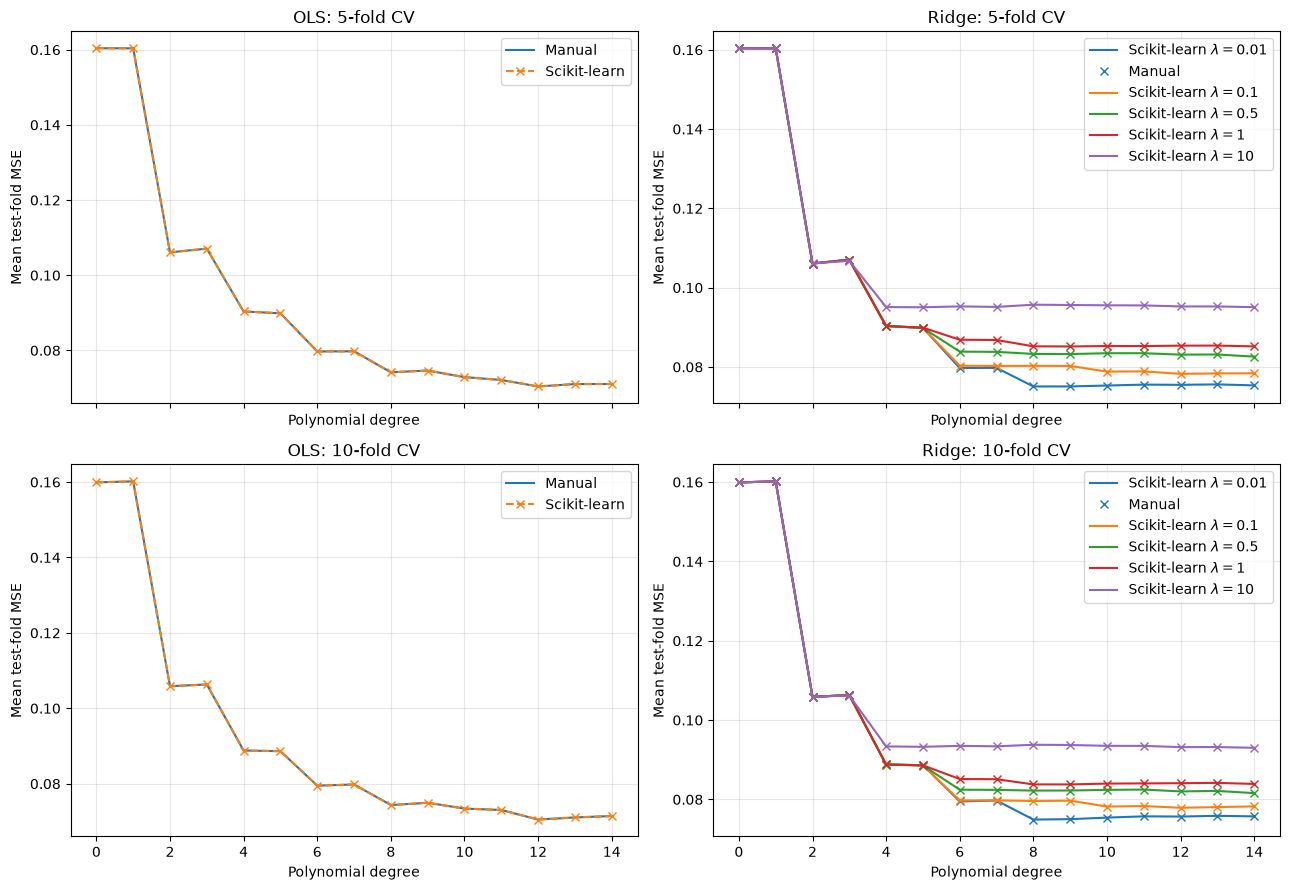

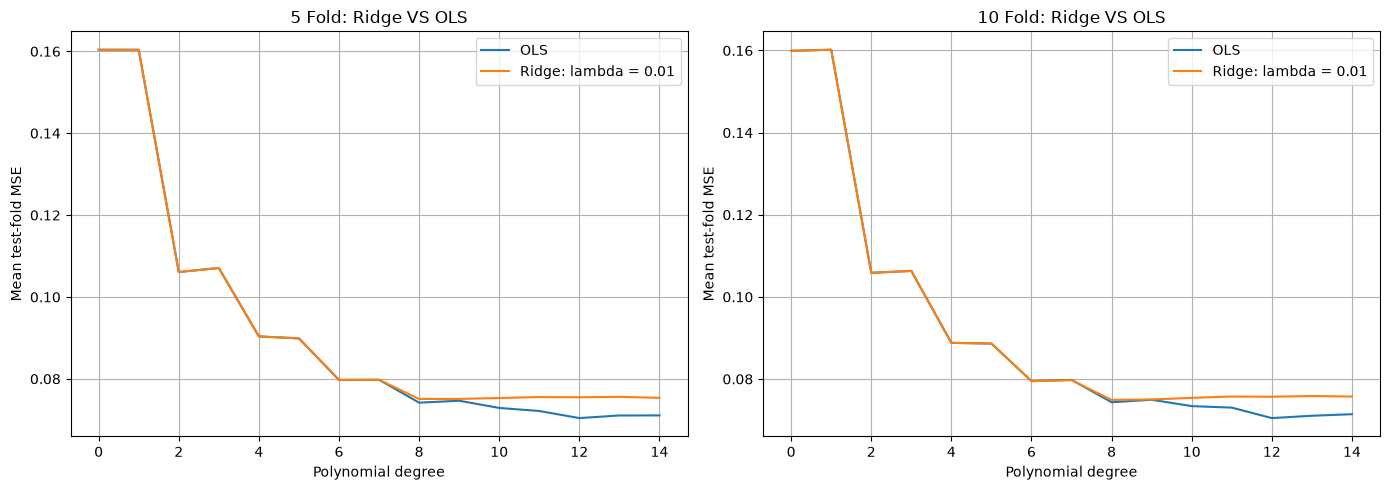

In [16]:
def Kfold_CV(k, deg, lmb=0): # OLS med mindre lmb blir gitt verdi
    X = design_matrix(x, deg)
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    score_KFold = []
    
    for train_ind, test_ind in kfold.split(X):
        x_train, x_test = X[train_ind], X[test_ind]
        y_train, y_test = y[train_ind], y[test_ind]

        # Skalering
        # Beregn gjennomsnitt og standardavvik fra treningsdata
        mean = x_train.mean(axis=0)
        std = x_train.std(axis=0)

        # Behold konstantkolonnen intercept: (1 - 0) / 1 = 1
        mean[0] = 0
        std[0] = 1

        X_train_norm = (x_train - mean) / std
        X_test_norm = (x_test - mean) / std
        # Trenger ikke sentrere y da design matrisen inneholder intercept

        I = np.eye(X_train_norm.shape[1])
        I[0,0] = 0.0 # Vil ikke straffe intercept i Ridge regresjon

        if lmb == 0:
            theta = np.linalg.pinv(X_train_norm) @ y_train
        else:
            theta = (
                np.linalg.pinv(X_train_norm.T @ X_train_norm + lmb * I)
                @ X_train_norm.T @ y_train)

        y_predict = X_test_norm @ theta 
        mse = np.mean((y_test - y_predict)**2)
        score_KFold.append(mse)
    mse_Kfold = np.mean(score_KFold)
    mse_std = np.std(score_KFold, ddof=1)
    return mse_Kfold, mse_std


def sklearn_kfold(folds, degree, lmb=None):
    X = design_matrix(x, degree)
    cv = KFold(n_splits=folds, shuffle=True, random_state=2026)

    if lmb is None:
        # X already includes the constant column.
        model = LinearRegression(fit_intercept=False)
    else:
        model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=lmb, fit_intercept=True, solver="svd")
        )

    fold_mse = -cross_val_score(
        model, X, y,
        cv=cv,
        scoring="neg_mean_squared_error",
        error_score="raise"
    )

    return fold_mse.mean(), fold_mse.std(ddof=1)

degrees = np.arange(maxdeg)
fold_counts = [5, 10]
ridge_lambdas = [0.01, 0.1, 0.5, 1.0, 10.0]

ols_cv = {}
ridge_cv = {}

for folds in fold_counts:
    # Kolonne 0: gjennomsnittlig MSE
    # Kolonne 1: standardavvik mellom foldene
    ols_cv[folds] = np.array([
        Kfold_CV(folds, degree, 0.0)
        for degree in degrees
    ])

    for lmb in ridge_lambdas:
        ridge_cv[(folds, lmb)] = np.array([
            Kfold_CV(folds, degree, lmb)
            for degree in degrees
        ])

# Hent de lagrede manuelle resultatene; beregn Scikit-learn som kontroll.
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for row, folds in enumerate(fold_counts):
    manual = ols_cv[folds][:, 0]  # MSE for hver polynomgrad
    std = ols_cv[folds][:, 1]     # Standardavvik mellom foldene
    sklearn_mse = np.array([
        sklearn_kfold(folds, degree)[0] for degree in degrees
    ])

    ax = axes[row, 0]
    ax.plot(degrees, manual, label="Manual")
    ax.plot(degrees, sklearn_mse, "x--", label="Scikit-learn")
    ax.set_title(f"OLS: {folds}-fold CV")
    print(f"OLS, k={folds}: maximum absolute MSE difference = "
          f"{np.max(np.abs(manual - sklearn_mse)):.3e}")

    ax = axes[row, 1]
    for lmb in ridge_lambdas:
        manual = ridge_cv[(folds, lmb)][:, 0]
        std = ridge_cv[(folds, lmb)][:, 1]
        sklearn_mse = np.array([
            sklearn_kfold(folds, degree, lmb)[0] for degree in degrees
        ])
        line, = ax.plot(degrees, sklearn_mse,
                        label=rf"Scikit-learn $\lambda={lmb:g}$")
        ax.plot(degrees, manual, "x", color=line.get_color(),
                label="Manual" if lmb == ridge_lambdas[0] else "_nolegend_")
        print(f"Ridge, k={folds}, lambda={lmb:g}: maximum absolute MSE difference = "
              f"{np.max(np.abs(manual - sklearn_mse)):.3e}")
    ax.set_title(f"Ridge: {folds}-fold CV")

for ax in axes.flat:
    ax.set_xlabel("Polynomial degree")
    ax.set_ylabel("Mean test-fold MSE")
    ax.grid(alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()



ols_5 = ols_cv[5][:, 0]
ols_10 = ols_cv[10][:, 0]

ridge_5 = ridge_cv[(5, 0.01)][:, 0]
ridge_10 = ridge_cv[(10, 0.01)][:, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, folds, ols, ridge in [
    (axes[0], 5, ols_5, ridge_5),
    (axes[1], 10, ols_10, ridge_10),
]:
    ax.plot(degrees, ols, label="OLS")
    ax.plot(degrees, ridge, label="Ridge: lambda = 0.01")
    ax.set_title(f"{folds} Fold: Ridge VS OLS")
    ax.set_ylabel("Mean test-fold MSE")
    ax.set_xlabel("Polynomial degree")
    ax.legend()
    ax.grid()

axes[1].set_xlabel("Polynomial degree")

fig.tight_layout()
plt.show()

# Koden under VIL få følgefeil, den må endres, men da må Bootstrap inkluderes og dette må kalles for BV-Tradeoff_Full

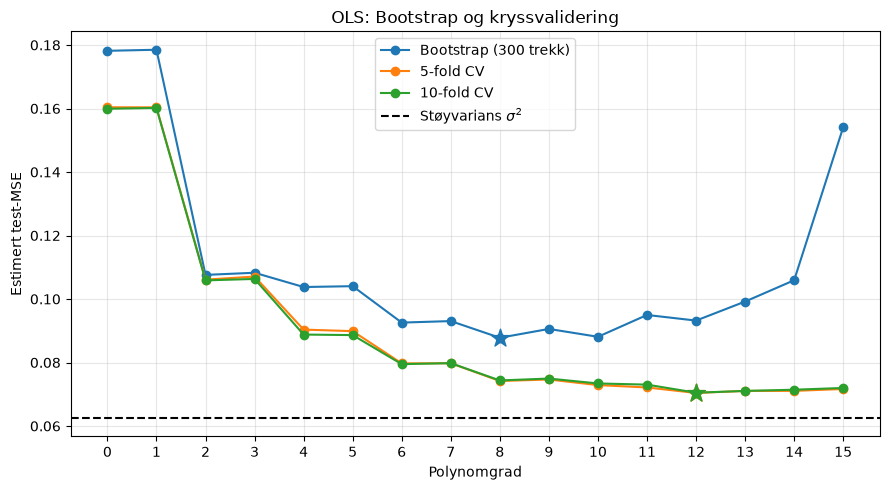

,Beste polynomgrad,Laveste estimert MSE
Metode,,
Bootstrap (300 trekk),8,0.087795
5-fold CV,12,0.070415
10-fold CV,12,0.070490


In [27]:
# Plot CV vs Bootstrap her
# Kjør bootstrap-cellen og K-fold-cellen før denne cellen.
comparison_degrees = np.arange(len(error300))

cv5_mse = np.array([
    Kfold_CV(5, degree, lmb=0)[0]
    for degree in comparison_degrees
])
cv10_mse = np.array([
    Kfold_CV(10, degree, lmb=0)[0]
    for degree in comparison_degrees
])

comparison_results = {
    "Bootstrap (300 trekk)": error300,
    "5-fold CV": cv5_mse,
    "10-fold CV": cv10_mse,
}

fig, ax = plt.subplots(figsize=(9, 5))
summary_rows = []

for method, errors in comparison_results.items():
    best_index = np.argmin(errors)
    best_degree = comparison_degrees[best_index]

    line, = ax.plot(
        comparison_degrees, errors, marker="o", label=method
    )
    ax.scatter(
        best_degree, errors[best_index],
        marker="*", s=180, color=line.get_color(), zorder=3
    )

    summary_rows.append({
        "Metode": method,
        "Beste polynomgrad": int(best_degree),
        "Laveste estimert MSE": errors[best_index],
    })

ax.axhline(
    sigma**2, color="black", linestyle="--",
    label=r"Støyvarians $\sigma^2$"
)
ax.set(
    title="OLS: Bootstrap og kryssvalidering",
    xlabel="Polynomgrad",
    ylabel="Estimert test-MSE",
)
ax.set_xticks(comparison_degrees)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

display(pd.DataFrame(summary_rows).set_index("Metode"))

In [28]:
def lasso_kfold(folds, degree, alpha):
    X = design_matrix(x, degree)
    cv = KFold(
        n_splits=folds,
        shuffle=True,
        random_state=2026,
    )

    model = make_pipeline(
        StandardScaler(),
        Lasso(
            alpha=alpha,
            fit_intercept=True,
            max_iter=100000,
            tol=1e-6,
        ),
    )

    fold_mse = -cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_squared_error",
        error_score="raise",
    )

    return fold_mse.mean(), fold_mse.std(ddof=1)


lasso_alphas = np.logspace(-3, -1, 7)
lasso_cv = {}

for folds in fold_counts:
    for alpha in lasso_alphas:
        lasso_cv[(folds, alpha)] = np.array([
            lasso_kfold(folds, degree, alpha)
            for degree in degrees
        ])

In [29]:
rows = []

for folds in fold_counts:
    models = [
        ("OLS", np.nan, ols_cv[folds]),
        *[
            ("Ridge", lmb, ridge_cv[(folds, lmb)])
            for lmb in ridge_lambdas
        ],
        *[
            ("Lasso", alpha, lasso_cv[(folds, alpha)])
            for alpha in lasso_alphas
        ],
    ]

    for model, penalty, scores in models:
        for degree, (mse, std) in zip(degrees, scores):
            rows.append({
                "Modell": model,
                "Folds": folds,
                "Grad": degree,
                "Alpha": penalty,
                "MSE": mse,
                "Std": std,
            })

results_df = pd.DataFrame(rows)

best_indices = results_df.groupby("Folds")["MSE"].idxmin()
best_models = results_df.loc[best_indices].sort_values("Folds")

display(best_models)

,Modell,Folds,Grad,Alpha,MSE,Std
12,OLS,5,12,NaN,0.070415,0.012992
207,OLS,10,12,NaN,0.070490,0.016129


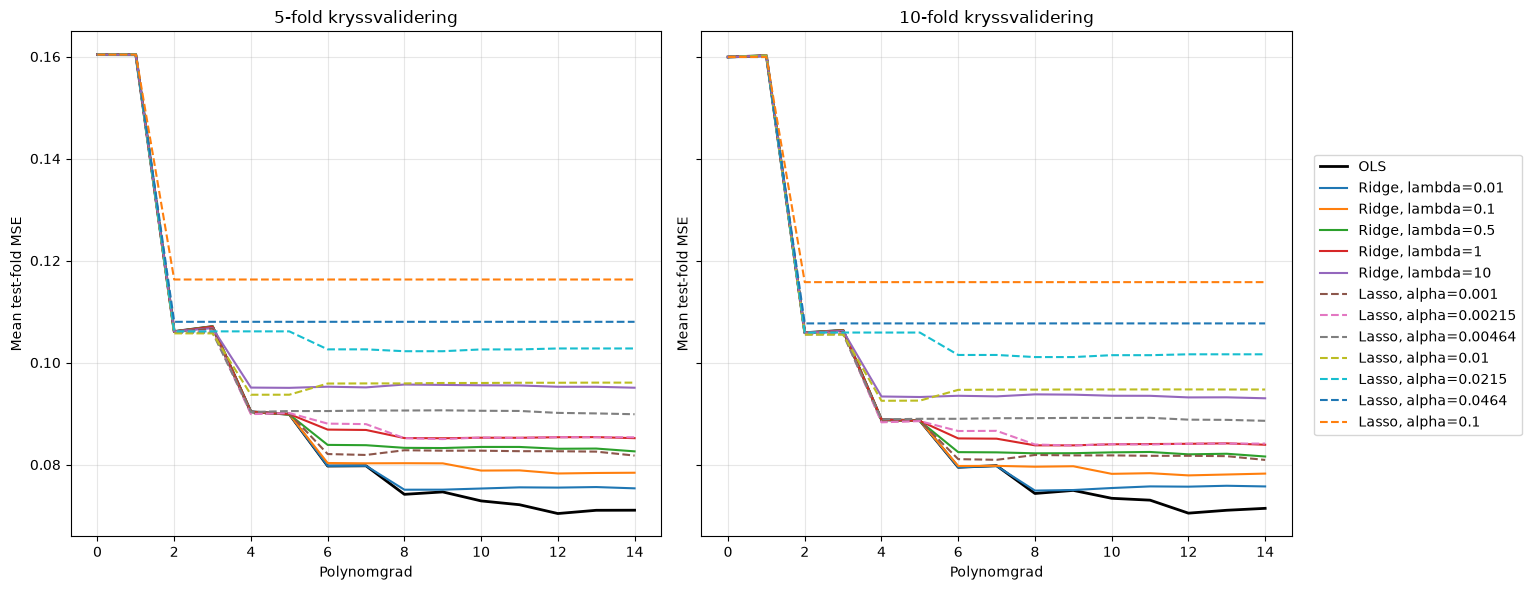

In [30]:
# Gjenbruk OLS og Ridge fra d); Lasso-resultatene er beregnet ovenfor.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

for ax, folds in zip(axes, fold_counts):
    ax.plot(degrees, ols_cv[folds][:, 0], color="black", linewidth=2,
            label="OLS")

    for lmb in ridge_lambdas:
        ax.plot(degrees, ridge_cv[(folds, lmb)][:, 0],
                linestyle="-", label=f"Ridge, lambda={lmb:g}")

    for alpha in lasso_alphas:
        ax.plot(degrees, lasso_cv[(folds, alpha)][:, 0],
                linestyle="--", label=f"Lasso, alpha={alpha:.3g}")

    ax.set(title=f"{folds}-fold kryssvalidering",
           xlabel="Polynomgrad", ylabel="Mean test-fold MSE")
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.82, 0.5))
fig.tight_layout(rect=(0, 0, 0.82, 1))
plt.show()


Best Model OLS 12 degrees:
Best Model Ridge : lambda = 0.01 8 degrees
Best model Lasso: alpha = 0.001 6 degrees. 

 Which of the terms in the bias-variance decomposition of part c)
does each method attack, and does your numerical evidence support that reading?


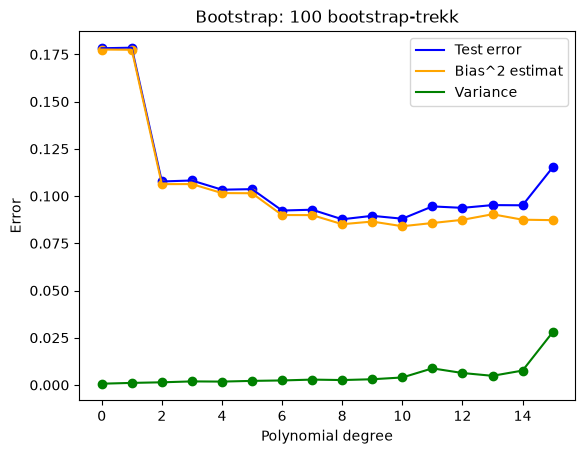

In [32]:
plt.plot(degree_vec, error100, label="Test error", color="blue")
plt.scatter(degree_vec, error100, color="blue")
plt.plot(degree_vec, bias100, label="Bias^2 estimat", color="orange")
plt.scatter(degree_vec, bias100, color="orange")
plt.plot(degree_vec, variance100, label="Variance", color="green")
plt.scatter(degree_vec, variance100, color="green")
plt.title("Bootstrap: 100 bootstrap-trekk")
plt.xlabel("Polynomial degree")
plt.ylabel("Error")
plt.legend()    
plt.show()